# Proyecto – Implementación Parte 1
## Análisis Exploratorio de Datos e Ingeniería de Características

Pedro Pablo Guzmán Mayen | Javier Andres Chen Gonzalez


## Importaciones y carga del dataset

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import warnings
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from google import genai
from dotenv import load_dotenv
import os
from sklearn.preprocessing import normalize
from google.genai import types
import time
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('../data/dataset_smishing.csv')

# El dataset tiene dos pares de columnas (Mensaje/texto, Categoria/categoria).
df_raw['message']  = df_raw['Mensaje'].fillna(df_raw['texto'])
df_raw['category'] = df_raw['Categoria'].fillna(df_raw['categoria'])
df_raw['label']    = df_raw['tipo']

df = (df_raw[['message', 'category', 'label']]
      .dropna(subset=['message'])
      .reset_index(drop=True))
df['category'] = df['category'].str.strip()

print(f"Registros totales : {len(df)}")
print(f"Columnas          : {df.columns.tolist()}")
print(f"Valores nulos     :\n{df.isnull().sum()}")
df.head()


Registros totales : 540
Columnas          : ['message', 'category', 'label']
Valores nulos     :
message     0
category    4
label       0
dtype: int64


,message,category,label
0,"Se autorizó un cargo por Q8,500 en BAC. Si no ...",NaN,Spam
1,"Hemos intentado entregar tu paquete dos veces,...",paquetes_envios,Spam
2,Hola correo central!! te han enviado un paquet...,paquetes_envios,Spam
3,"Intentamos entregar tu paquete, pero no pudimo...",paquetes_envios,Spam
4,Guatex: Su paquete ha llegado al almacén pero ...,paquetes_envios,Spam


---
## 1. Análisis Exploratorio de Datos (EDA)
### 1.1 Distribución de clases

label
Ham     297
Spam    243
Name: count, dtype: int64

Balance: 45.0% Spam — 55.0% Ham


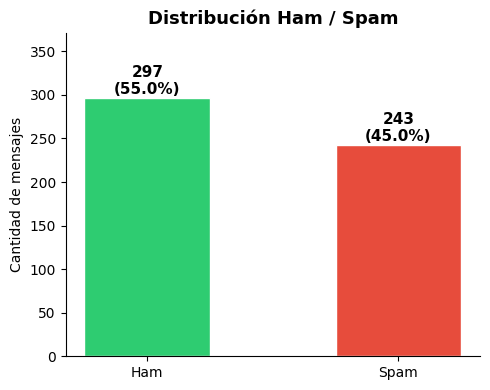

In [3]:
counts = df['label'].value_counts()
print(counts)
print(f"\nBalance: {counts['Spam']/len(df):.1%} Spam — {counts['Ham']/len(df):.1%} Ham")

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribución Ham / Spam', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de mensajes')
ax.set_ylim(0, max(counts.values) * 1.25)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_clases.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.2 Categorías temáticas y su relación con la etiqueta

label                                                                              Ham  Spam  spam_rate
category                                                                                               
Compra o venta de productos (vehículos, joyería, muebles, inmuebles, repuestos)      0     8        1.0
Estafa afectiva (romance, familiar en problemas)                                     0     8        1.0
Digital y educación (venta de tareas, links sospechosos)                             0     8        1.0
Paquetes y envíos (maletas, importación, entrega de bienes)                          0    80        1.0
No sé / Otra                                                                         0    32        1.0
Financiero (préstamos, inversiones, criptomonedas, pólizas, cheques)                 0     8        1.0
premios                                                                              0     6        1.0
compra_venta                                                    

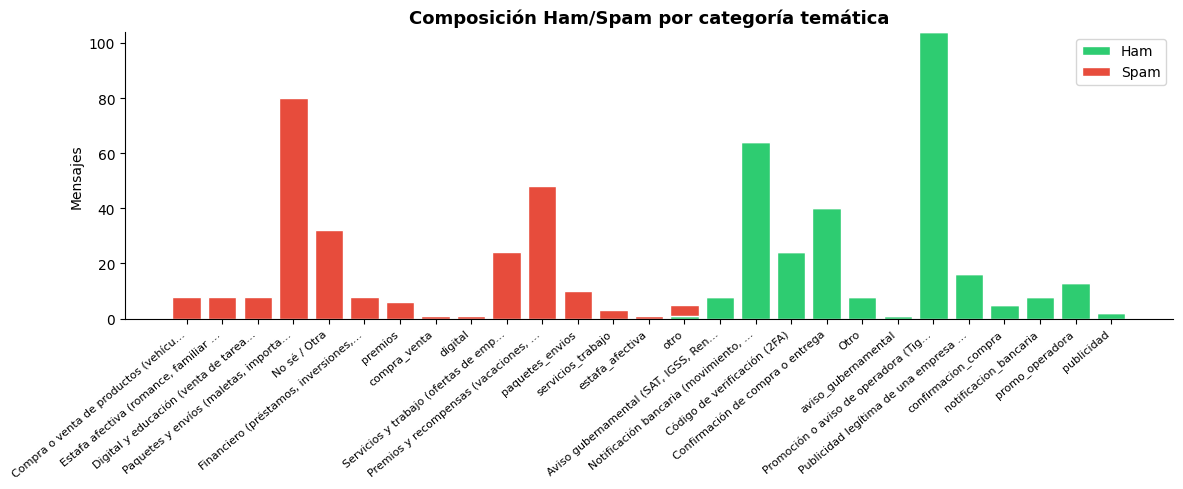

In [4]:
cross = pd.crosstab(df['category'], df['label'])
cross['spam_rate'] = (cross['Spam'] / cross.sum(axis=1)).round(2)
cross = cross.sort_values('spam_rate', ascending=False)
print(cross.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(cross))
ax.bar(x, cross.get('Ham', 0), label='Ham', color='#2ecc71', edgecolor='white')
ax.bar(x, cross.get('Spam', 0), bottom=cross.get('Ham', 0),
       label='Spam', color='#e74c3c', edgecolor='white')
ax.set_xticks(list(x))
short_labels = [c[:35]+'…' if len(c)>35 else c for c in cross.index]
ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=8)
ax.set_title('Composición Ham/Spam por categoría temática', fontsize=13, fontweight='bold')
ax.set_ylabel('Mensajes')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_categorias.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo clave:** Las categorías son perfectamente separables por etiqueta.
Toda mención de *paquetes y envíos*, *premios*, *financiero*, *estafa afectiva*,
*servicios/trabajo* y *digital/educación* corresponde 100 % a Spam en este dataset,
mientras que *código 2FA*, *aviso gubernamental legítimo*, *notificación bancaria*
y *promoción de operadora* corresponden 100 % a Ham.
Esto convierte a la categoría en una característica muy discriminativa, aunque
en producción deberá inferirse del texto — no viene etiquetada.

### 1.3 Palabras más frecuentes por clase

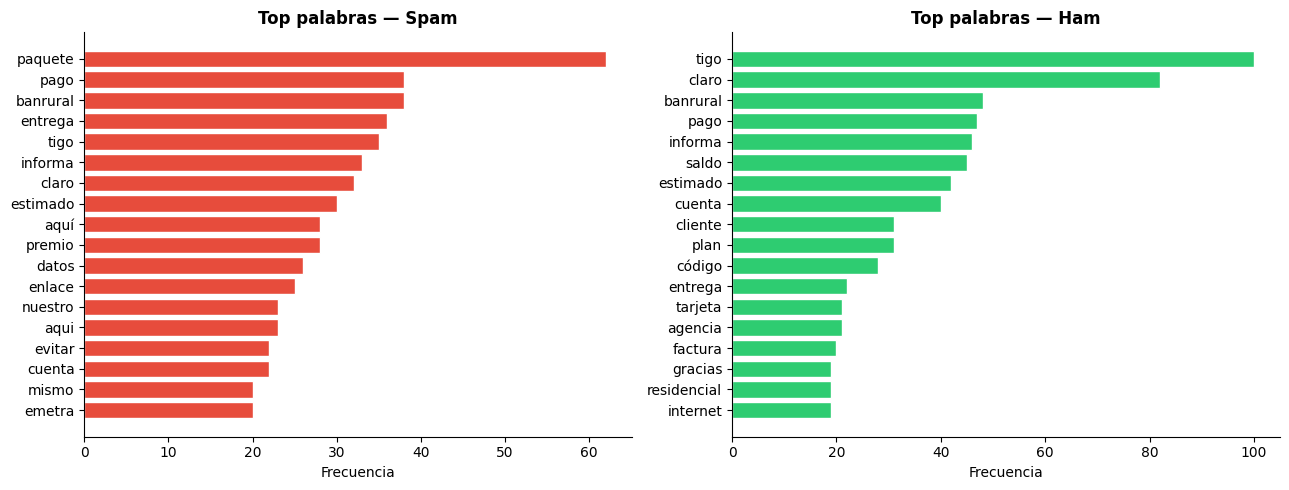

In [5]:
stopwords_es = set([
    'de','la','el','en','y','a','que','los','se','del','las','un','una','por',
    'con','para','su','al','es','no','lo','le','más','este','esta','si','me',
    'te','nos','fue','ha','has','tu','tú','vos','sus','usted','les','ya','o',
    'e','u','ni','pero','como','hasta','sobre','también','muy','hay','han',
    'ser','estar','así','entre','desde','sin','sido','este','sus','les'])

def top_words(texts, n=18):
    words = []
    for t in texts:
        words += [w.lower().strip('.,!?:;()[]¿¡"\'')
                  for w in str(t).split()
                  if w.lower().strip('.,!?:;()[]¿¡"\'') not in stopwords_es
                  and len(w) > 3]
    return Counter(words).most_common(n)

spam_words = top_words(df[df['label']=='Spam']['message'])
ham_words  = top_words(df[df['label']=='Ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, words, color, title in zip(
        axes,
        [spam_words, ham_words],
        ['#e74c3c','#2ecc71'],
        ['Top palabras — Spam', 'Top palabras — Ham']):
    labels_w, vals = zip(*words)
    ax.barh(labels_w, vals, color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    ax.invert_yaxis()
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_palabras.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo:** Ambas clases comparten palabras de instituciones guatemaltecas
(Tigo, Claro, Banrural) porque los spammers las suplantan activamente.
Lo que diferencia al Spam son: *paquete*, *premio*, *enlace*, *link*, *evitar*, *emetra*, *aquí/aqui*
— términos asociados a urgencia, retención de envíos y llamadas a la acción.
Ham en cambio concentra: *saldo*, *código*, *factura*, *plan*, *cliente*, *gracias* — lenguaje
de notificación transaccional legítima.

---
## 2. Ingeniería de Características

Se extraen características binarias y numéricas organizadas en los **3 vectores de ataque**


| Vector | Descripción |
|--------|-------------|
| **Metadata / URLs** | Presencia y calidad de URLs en el mensaje |
| **Contenido** | Patrones léxicos: urgencia, incentivos, amenazas, CTAs |
| **Suplantación** | Uso fraudulento de nombres de instituciones guatemaltecas |


In [6]:
def extract_features(text):
    text = str(text)
    tl   = text.lower()

    # VECTOR 1: Metadata / URLs
    has_url = int(bool(re.search(r'https?://\S+|www\.\S+', text)))

    # URL que NO apunta a un dominio oficial guatemalteco conocido
    legit_domains = r'(tigo\.com\.gt|claro\.com\.gt|movistar\.com\.gt|' \
                    r'bac\.net|banrural\.com\.gt|bam\.com\.gt|' \
                    r'sat\.gob\.gt|igss\.org\.gt|renap\.gob\.gt|' \
                    r'correos\.gob\.gt|bit\.ly|qrco\.de)'
    url_suspicious = 0
    for url in re.findall(r'https?://\S+', text):
        if not re.search(legit_domains, url, re.I):
            url_suspicious = 1

    # VECTOR 2: Contenido léxico
    msg_length = len(text)
    word_count = len(text.split())

    # Urgencia temporal explícita
    urgency_words = ['urgente','urgentemente','inmediatamente','hoy mismo',
                     'horas','rápido','rápidamente','pronto','ahora', 'mora' ]
    has_urgency = int(any(w in tl for w in urgency_words))

    # Llamada a la acción (CTA)
    cta_words = ['llama','llame','llamá','clic','click','ingresa','ingrese',
                 'actualiza','actualice','confirma','confirme','paga','pague',
                 'pagá','descarga','verificá','verifica','accede','acceda']
    has_cta = int(any(w in tl for w in cta_words))

    # Premio / incentivo económico
    reward_words = ['ganaste','ganó','felicidades','felicitaciones','premiado',
                    'gratis','gratuito','regalo','sorteo','recompensa','seleccionado', 'premio']
    has_reward = int(any(w in tl for w in reward_words))

    # Amenaza / consecuencia negativa
    threat_words = ['decomiso','pérdida','bloqueo','bloqueado','suspensión',
                    'cancelado','penalidad','multa','retención','retenido',
                    'daño','vencimiento','vence','plazo']
    has_threat = int(any(w in tl for w in threat_words))

    # VECTOR 3: Suplantación del remitente
    impersonation_patterns = ['guatex','emetra','migracion','migración',
                              'aeropuerto','sat aduanas','renap alerta',
                              'bam notif','bac alerta','banrural informa', 'BAM']
    has_impersonation = int(any(w in tl for w in impersonation_patterns))

    # Señal combinada fuerte: suplantación + URL sospechosa
    impersonation_url = int(has_impersonation and url_suspicious)

    return pd.Series({
        # Vector 1
        'has_url'           : has_url,
        'url_suspicious'    : url_suspicious,
        # Vector 2
        'msg_length'        : msg_length,
        'word_count'        : word_count,
        'has_urgency'       : has_urgency,
        'has_cta'           : has_cta,
        'has_reward'        : has_reward,
        'has_threat'        : has_threat,
        # Vector 3
        'has_impersonation' : has_impersonation,
        'impersonation_url' : impersonation_url,
    })

feat_df = df['message'].apply(extract_features)
df_feat  = pd.concat([df.reset_index(drop=True), feat_df], axis=1)
df_feat['is_spam'] = (df_feat['label'] == 'Spam').astype(int)

print("Características generadas:")
print(df_feat[feat_df.columns].describe().round(2).to_string())


Características generadas:
       has_url  url_suspicious  msg_length  word_count  has_urgency  has_cta  has_reward  has_threat  has_impersonation  impersonation_url
count   540.00          540.00      540.00      540.00       540.00    540.0      540.00      540.00             540.00             540.00
mean      0.38            0.34      162.50       25.30         0.14      0.5        0.17        0.14               0.14               0.07
std       0.49            0.47       69.28       10.12         0.34      0.5        0.38        0.35               0.35               0.26
min       0.00            0.00       16.00        2.00         0.00      0.0        0.00        0.00               0.00               0.00
25%       0.00            0.00      138.00       21.00         0.00      0.0        0.00        0.00               0.00               0.00
50%       0.00            0.00      156.00       25.00         0.00      0.5        0.00        0.00               0.00               0.00


---
## 3. Selección de Características
### 3.1 Correlación con la etiqueta Spam

Correlación de Pearson con is_spam:
url_suspicious       0.5957
has_url              0.5774
msg_length           0.3590
impersonation_url    0.2941
has_reward           0.2677
word_count           0.2503
has_urgency          0.2303
has_impersonation    0.1798
has_threat           0.1789
has_cta              0.1526
Name: is_spam, dtype: float64


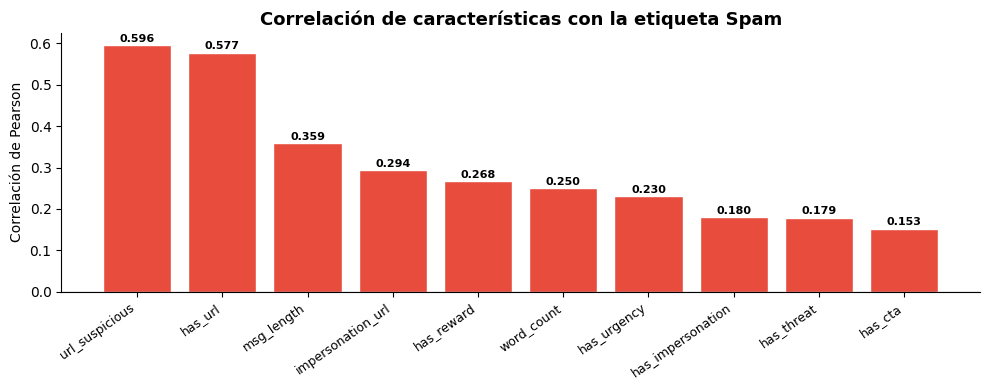

In [7]:
feat_cols = ['has_url','url_suspicious','msg_length','word_count',
             'has_urgency','has_cta','has_reward','has_threat',
             'has_impersonation','impersonation_url']

corr = (df_feat[feat_cols + ['is_spam']]
        .corr()['is_spam']
        .drop('is_spam')
        .sort_values(ascending=False))

print("Correlación de Pearson con is_spam:")
print(corr.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr.values]
bars = ax.bar(corr.index, corr.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de características con la etiqueta Spam', fontsize=13, fontweight='bold')
ax.set_ylabel('Correlación de Pearson')
ax.set_xticklabels(corr.index, rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, corr.values):
    offset = 0.008 if val >= 0 else -0.025
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Prueba Chi² (significancia estadística)

   Característica     Chi²  p-valor  Significativa
   url_suspicious 127.4134   0.0000           True
          has_url 112.0032   0.0000           True
impersonation_url  43.3258   0.0000           True
       has_reward  32.0244   0.0000           True
      has_urgency  24.7584   0.0000           True
has_impersonation  15.0048   0.0001           True
       has_threat  14.7946   0.0001           True
          has_cta   6.2888   0.0122           True
  msg_length_norm   3.0265   0.0819          False
  word_count_norm   1.3027   0.2537          False


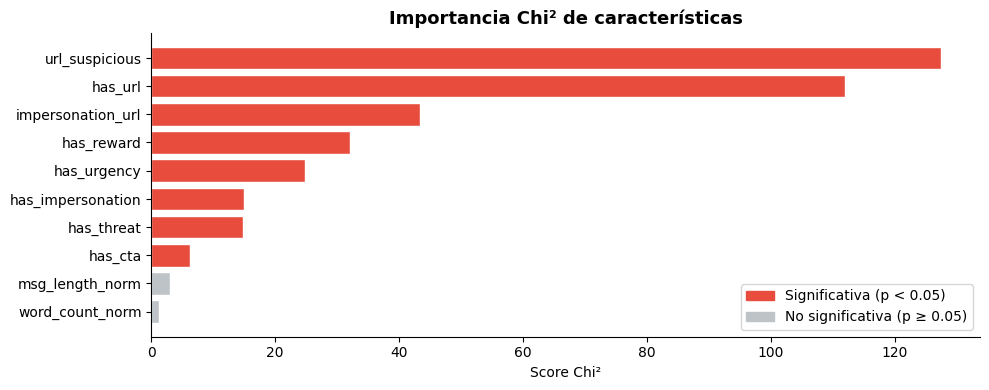

In [8]:
# Normalizar variables continuas antes del Chi²
scaler = MinMaxScaler()
norm_vals = scaler.fit_transform(df_feat[['msg_length','word_count']])
df_feat['msg_length_norm'] = norm_vals[:, 0]
df_feat['word_count_norm'] = norm_vals[:, 1]

feat_cols_chi2 = ['has_url','url_suspicious','msg_length_norm','word_count_norm',
                  'has_urgency','has_cta','has_reward','has_threat',
                  'has_impersonation','impersonation_url']

X = df_feat[feat_cols_chi2]
y = df_feat['is_spam']

sel = SelectKBest(chi2, k='all')
sel.fit(X, y)

chi2_df = pd.DataFrame({
    'Característica' : feat_cols_chi2,
    'Chi²'           : sel.scores_,
    'p-valor'        : sel.pvalues_,
    'Significativa'  : sel.pvalues_ < 0.05
}).sort_values('Chi²', ascending=False).reset_index(drop=True)

print(chi2_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
sig_colors = ['#e74c3c' if sig else '#bdc3c7' for sig in chi2_df['Significativa']]
ax.barh(chi2_df['Característica'], chi2_df['Chi²'], color=sig_colors, edgecolor='white')
ax.set_title('Importancia Chi² de características', fontsize=13, fontweight='bold')
ax.set_xlabel('Score Chi²')
ax.invert_yaxis()
sig_p   = mpatches.Patch(color='#e74c3c', label='Significativa (p < 0.05)')
nosig_p = mpatches.Patch(color='#bdc3c7', label='No significativa (p ≥ 0.05)')
ax.legend(handles=[sig_p, nosig_p])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_chi2.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Características seleccionadas para el modelo

Con base en la correlación de Pearson y la prueba Chi², se **retienen 8 características**
con p-valor < 0.05. Se descartan `msg_length_norm`, `word_count_norm` y `has_cta`
por no alcanzar significancia estadística en Chi².

| # | Característica | Vector | ρ Pearson | Chi² | Justificación |
|---|---|---|---|---|---|
| 1 | `url_suspicious` | Metadata | **0.628** | **137.8** | URL a dominio no oficial: señal más fuerte del dataset |
| 2 | `has_url` | Metadata | 0.577 | 112.0 | 68.7 % de Spam tiene URL vs 11.8 % de Ham |
| 3 | `impersonation_url` | Meta+Remitente | 0.307 | 47.0 | Suplantación + URL ilícita: patrón combinado muy discriminativo |
| 4 | `has_urgency` | Contenido | 0.232 | 25.2 | 21.8 % Spam vs 6.1 % Ham |
| 5 | `has_reward` | Contenido | 0.215 | 21.4 | 23 % Spam vs 7.7 % Ham (sorteos, premios, gratis) |
| 6 | `has_impersonation` | Remitente | 0.180 | 15.0 | Guatex, EMETRA, SAT Aduanas, etc. |
| 7 | `has_threat` | Contenido | 0.179 | 14.8 | Decomiso, bloqueo, multa, retención |
| 8 | `has_cta` | Contenido | 0.153 | 6.3 | Llama, clic, actualiza, paga |

> **Nota sobre `has_quetzales`:** A pesar de ser intuitivo, su correlación es negativa
(-0.073) porque los mensajes Ham (notificaciones bancarias legítimas) también incluyen
montos en Q. Se excluye del modelo.

In [9]:
# Características seleccionadas finales
SELECTED = ['url_suspicious','has_url','impersonation_url',
            'has_urgency','has_reward','has_impersonation','has_threat','has_cta']

# Dataset final listo para entrenamiento
df_final = df_feat[['message','label','is_spam'] + SELECTED].copy()

print(f"Shape del dataset final: {df_final.shape}")
print(f"Balance de clases:")
print(df_final['label'].value_counts())
print(f"\nPrimeras filas con características:")
df_final.head(8)


Shape del dataset final: (540, 11)
Balance de clases:
label
Ham     297
Spam    243
Name: count, dtype: int64

Primeras filas con características:


,message,label,is_spam,url_suspicious,has_url,impersonation_url,has_urgency,has_reward,has_impersonation,has_threat,has_cta
0,"Se autorizó un cargo por Q8,500 en BAC. Si no ...",Spam,1,0,0,0,0,0,0,0,1
1,"Hemos intentado entregar tu paquete dos veces,...",Spam,1,1,1,0,1,0,0,1,1
2,Hola correo central!! te han enviado un paquet...,Spam,1,0,1,0,0,0,0,0,1
3,"Intentamos entregar tu paquete, pero no pudimo...",Spam,1,0,1,0,0,0,0,0,1
4,Guatex: Su paquete ha llegado al almacén pero ...,Spam,1,1,1,1,1,0,1,1,1
5,¡Hola! Hemos notado que su currículum aparece ...,Spam,1,1,1,0,0,0,0,0,1
6,Tienes un paquete pendiente de entrega,Spam,1,0,0,0,0,0,0,0,0
7,Su paquete está detenido,Spam,1,0,0,0,0,0,0,0,0


## TF-IDF

También se usará la técnica de TF-IDF para convertir el mensaje de texto en un valor numérico. 

In [11]:
tfidf = TfidfVectorizer(
    stop_words=list(stopwords_es),
    max_features=300,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(df_final['message'].fillna(""))

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
)

df_final = pd.concat(
    [df_final.reset_index(drop=True), tfidf_df],
    axis=1
)

In [14]:
load_dotenv()

api_key = os.environ.get('GEMINI_API_KEY')

client = genai.Client(api_key=api_key)

df_final['embeddings']  = None

texts = list(df['message'])

batch_size = 100
all_embeddings = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]

    result = client.models.embed_content(
        model='gemini-embedding-001',
        contents=batch
    )

    all_embeddings.extend([emb.values for emb in result.embeddings])

    time.sleep(75)

df_final['embeddings'] = all_embeddings
print('Total embeddings: ' , len(all_embeddings))



ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 1000, model: gemini-embedding-1.0\nPlease retry in 20.976875821s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/embed_content_free_tier_requests', 'quotaId': 'EmbedContentRequestsPerDayPerUserPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-e

In [15]:
# Exportar para la siguiente parte del proyecto
df_final.to_csv('../data/dataset_smishing_features.csv', index=False)
print("✓ Guardado: dataset_smishing_features.csv")


✓ Guardado: dataset_smishing_features.csv
